## Notebook 05 — Deep Learning Models

### Purpose
This notebook trains and evaluates LSTM and GRU deep learning models 
on the Brent crude oil price series. Both models process sliding 
windows of 60 consecutive daily closing prices to predict the next 
day's price (sequence_length=60 ≈ one trading quarter).

### Why LSTM and GRU?
- Daneshvar et al. (2022) achieved LSTM RMSE=1.53 on Brent data 
  from the same Investing.com source (2015–2021)
- Awijen et al. (2023) found LSTM outperformed SVM during oil 
  price crisis periods
- Zhang and Lahmiri (2025) found GRU the best standalone deep 
  learning model on Brent data

### Input shape
(samples, 60, 1) — 60 time steps, 1 feature (univariate)

### Benchmark to beat
Random Forest RMSE = 1.3744 $/barrel

### Outputs
| File | Path |
|------|------|
| lstm_test_predictions.csv | results/lstm/ |
| lstm_metrics.json | results/lstm/ |
| gru_test_predictions.csv | results/gru/ |
| gru_metrics.json | results/gru/ |

In [1]:
import yaml
import os
import sys
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# Set project root
PROJECT_ROOT = r"C:\ml-vs-dl-models-for-brent-crude-oil-price-forecasting\UcheNlemadim-ml-vs-dl-models-for-brent-crude-oil-price-forecasting"
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
print("Working directory:", os.getcwd())

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Input
from tensorflow.keras.callbacks import (EarlyStopping, 
                                        ModelCheckpoint,
                                        ReduceLROnPlateau)
from tensorflow.keras.optimizers import Adam
import joblib

from src.preprocessing import load_config, load_and_clean, split_data
from src.evaluation import calculate_metrics, save_metrics, save_predictions

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

cfg = load_config("configs/config.yaml")
print("Config loaded successfully")
print(f"TensorFlow version: {tf.__version__}")

Working directory: C:\ml-vs-dl-models-for-brent-crude-oil-price-forecasting\UcheNlemadim-ml-vs-dl-models-for-brent-crude-oil-price-forecasting
Config loaded successfully
TensorFlow version: 2.21.0


In [2]:
# Load data and split
df = load_and_clean(cfg)
train, val, test = split_data(df, cfg)

# Load scaler fitted in NB01 — do NOT refit here
scaler = joblib.load(cfg["data"]["scaler_path"])
print(f"Scaler loaded.")
print(f"Scale range: [{scaler.data_min_[0]:.2f}, "
      f"{scaler.data_max_[0]:.2f}]")

# Scale all three splits
train_sc = scaler.transform(train.values.reshape(-1, 1))
val_sc   = scaler.transform(val.values.reshape(-1, 1))
test_sc  = scaler.transform(test.values.reshape(-1, 1))

print(f"\nScaled shapes:")
print(f"  train_sc: {train_sc.shape}")
print(f"  val_sc:   {val_sc.shape}")
print(f"  test_sc:  {test_sc.shape}")

Total rows retained: 6422; Date range: 2000-01-04 to 2024-12-31; Duplicates removed: 0
Train shape: (5389, 1); Val shape: (517, 1); Test shape: (516, 1)
Scaler loaded.
Scale range: [17.68, 146.08]

Scaled shapes:
  train_sc: (5389, 1)
  val_sc:   (517, 1)
  test_sc:  (516, 1)


In [3]:
# Sequence creation function
SEQ = cfg["models"]["lstm"]["sequence_length"]  # 60

def create_sequences(data: np.ndarray, seq_len: int):
    """
    Convert scaled price array into (X, y) sequence pairs.
    X shape: (samples, seq_len, 1) — univariate input
    y shape: (samples,)            — next day price (scaled)
    """
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i - seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(X).reshape(-1, seq_len, 1), np.array(y)

# Combine train and val for sequence generation
tv_sc    = np.vstack([train_sc, val_sc])
X_tv, y_tv = create_sequences(tv_sc, SEQ)

# Test sequences — use last SEQ points of tv as context
context   = tv_sc[-SEQ:]
full_test = np.vstack([context, test_sc])
X_test, y_test_sc = create_sequences(full_test, SEQ)

# Split X_tv back into train and val
val_size  = len(val)
X_train_s = X_tv[:-val_size]
y_train_s = y_tv[:-val_size]
X_val_s   = X_tv[-val_size:]
y_val_s   = y_tv[-val_size:]

print(f"Sequence length: {SEQ}")
print(f"X_train_s: {X_train_s.shape}")
print(f"X_val_s:   {X_val_s.shape}")
print(f"X_test:    {X_test.shape}")
assert X_test.shape[0] == len(test), "Test sequence count mismatch"
print("Sequence shapes verified.")

Sequence length: 60
X_train_s: (5329, 60, 1)
X_val_s:   (517, 60, 1)
X_test:    (516, 60, 1)
Sequence shapes verified.


In [4]:
# Build LSTM model
def build_lstm(cfg):
    lc = cfg["models"]["lstm"]
    model = Sequential([
        Input(shape=(lc["sequence_length"], 1)),
        LSTM(lc["units"][0], return_sequences=True,
             dropout=lc["dropout"]),
        LSTM(lc["units"][1], return_sequences=False,
             dropout=lc["dropout"]),
        Dense(25, activation="relu"),
        Dense(1)
    ], name="LSTM_model")
    model.compile(
        optimizer=Adam(learning_rate=lc["learning_rate"]),
        loss="mean_squared_error"
    )
    return model

lstm_model = build_lstm(cfg)
lstm_model.summary()

Model: "LSTM_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │           825 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,163 (117.82 KB)

 Trainable params: 30,163 (117.82 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Train LSTM model
lc = cfg["models"]["lstm"]
os.makedirs("results/lstm", exist_ok=True)

lstm_callbacks = [
    EarlyStopping(monitor="val_loss",
                  patience=lc["patience"],
                  restore_best_weights=True,
                  verbose=1),
    ModelCheckpoint("results/lstm/best_lstm_model.keras",
                    monitor="val_loss",
                    save_best_only=True,
                    verbose=0),
    ReduceLROnPlateau(monitor="val_loss",
                      factor=lc["lr_reduce_factor"],
                      patience=lc["lr_reduce_patience"],
                      verbose=1)
]

print("Training LSTM model...")
print("EarlyStopping patience=15 — will stop if no improvement.")

lstm_history = lstm_model.fit(
    X_train_s, y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=lc["epochs"],
    batch_size=lc["batch_size"],
    callbacks=lstm_callbacks,
    verbose=1
)
print("LSTM training complete.")

Training LSTM model...
EarlyStopping patience=15 — will stop if no improvement.
Epoch 1/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.0230 - val_loss: 0.0090 - learning_rate: 0.0010
Epoch 2/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0145 - val_loss: 0.0132 - learning_rate: 0.0010
Epoch 3/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.0129 - val_loss: 0.0180 - learning_rate: 0.0010
Epoch 4/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - loss: 0.0126 - val_loss: 0.0155 - learning_rate: 0.0010
Epoch 5/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - loss: 0.0129 - val_loss: 0.0142 - learning_rate: 0.0010
Epoch 6/100
166/167 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0124
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 0.0126 - val_loss: 0.0142 - learning_rate: 0.0010
Epoch 7/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.0114 - val_loss: 0.0130 - learning_rate: 5.0000e-04

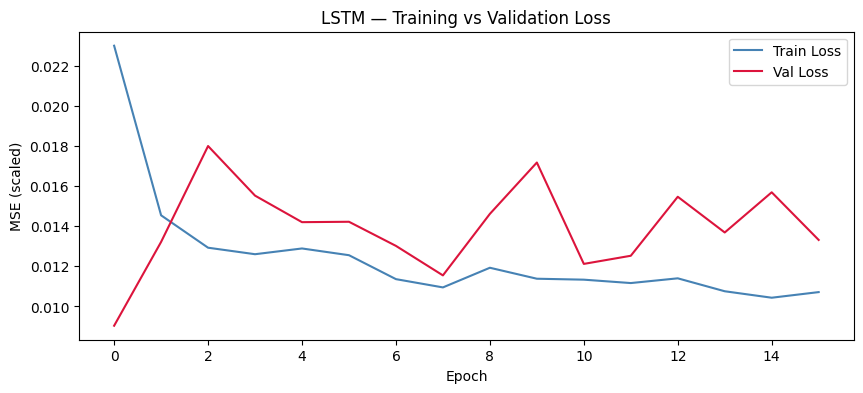

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
─── Metrics ──────────────────────
  RMSE : 9.9472 $/barrel
  MAE  : 9.4375 $/barrel
  MAPE : 11.5303 %

─── LSTM Test Set Metrics ────────────────────────────
  RMSE : 9.9472 $/barrel
  MAE  : 9.4375 $/barrel
  MAPE : 11.5303 %

Random Forest RMSE: 1.3744 $/barrel
LSTM vs RF: WORSE


In [6]:
# Plot training loss
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lstm_history.history["loss"],
        label="Train Loss", color="steelblue")
ax.plot(lstm_history.history["val_loss"],
        label="Val Loss", color="crimson")
ax.set_title("LSTM — Training vs Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (scaled)")
ax.legend()
plt.savefig("artifacts/plots/lstm_training_loss.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Predict and inverse transform to $/barrel
y_pred_lstm_sc = lstm_model.predict(X_test).flatten()
y_pred_lstm    = scaler.inverse_transform(
                     y_pred_lstm_sc.reshape(-1, 1)).flatten()
y_test_lstm    = scaler.inverse_transform(
                     y_test_sc.reshape(-1, 1)).flatten()
test_dates     = test.index[-len(y_test_lstm):]

metrics_lstm = calculate_metrics(y_test_lstm, y_pred_lstm)

print("\n─── LSTM Test Set Metrics ────────────────────────────")
print(f"  RMSE : {metrics_lstm['RMSE']:.4f} $/barrel")
print(f"  MAE  : {metrics_lstm['MAE']:.4f} $/barrel")
print(f"  MAPE : {metrics_lstm['MAPE']:.4f} %")
print(f"\nRandom Forest RMSE: 1.3744 $/barrel")
print(f"LSTM vs RF: {'BETTER' if metrics_lstm['RMSE'] < 1.3744 else 'WORSE'}")

In [7]:
# Rebuild and retrain LSTM with adjusted settings
tf.random.set_seed(42)
np.random.seed(42)

def build_lstm_v2(cfg):
    lc = cfg["models"]["lstm"]
    model = Sequential([
        Input(shape=(lc["sequence_length"], 1)),
        LSTM(lc["units"][0], return_sequences=True),
        LSTM(lc["units"][1], return_sequences=False),
        Dense(25, activation="relu"),
        Dense(1)
    ], name="LSTM_model_v2")
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mean_squared_error"
    )
    return model

lstm_model = build_lstm_v2(cfg)

# Adjusted callbacks — more patience, no dropout
lstm_callbacks2 = [
    EarlyStopping(monitor="val_loss",
                  patience=20,
                  restore_best_weights=True,
                  verbose=1),
    ModelCheckpoint("results/lstm/best_lstm_model.keras",
                    monitor="val_loss",
                    save_best_only=True,
                    verbose=0),
    ReduceLROnPlateau(monitor="val_loss",
                      factor=0.5,
                      patience=8,
                      min_lr=0.00001,
                      verbose=1)
]

print("Retraining LSTM with adjusted settings...")
lstm_history = lstm_model.fit(
    X_train_s, y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=150,
    batch_size=32,
    callbacks=lstm_callbacks2,
    verbose=1
)
print("LSTM retraining complete.")

Retraining LSTM with adjusted settings...
Epoch 1/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.0097 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 2/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 6.0322e-04 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 3/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 5.2669e-04 - val_loss: 0.0010 - learning_rate: 0.0010
Epoch 4/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 4.6730e-04 - val_loss: 9.5651e-04 - learning_rate: 0.0010
Epoch 5/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 4.3555e-04 - val_loss: 9.3609e-04 - learning_rate: 0.0010
Epoch 6/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 4.0631e-04 - val_loss: 9.2325e-04 - learning_rate: 0.0010
Epoch 7/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 3.7961e-04 - val_loss: 9.0905e-04 - learning_rate: 0.0010
Epoch 8/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 3.7292e-04 - val_loss: 0.0010 - learning_rate: 0.0010
Epoch 9/150
167/16

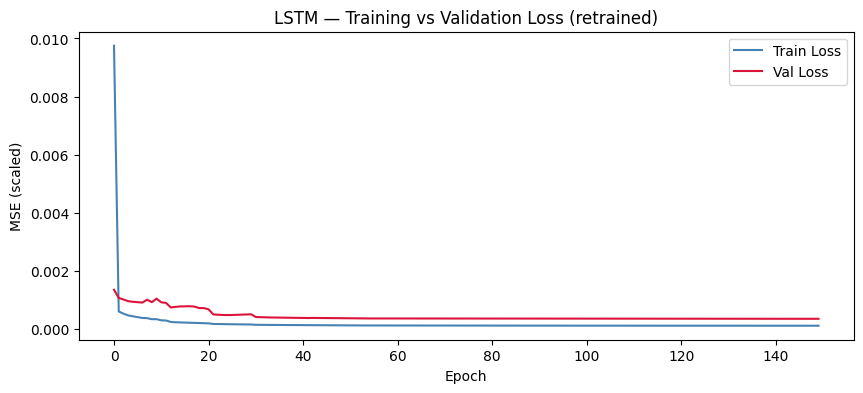

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
─── Metrics ──────────────────────
  RMSE : 1.4838 $/barrel
  MAE  : 1.1431 $/barrel
  MAPE : 1.4242 %

─── LSTM Test Set Metrics ────────────────────────────
  RMSE : 1.4838 $/barrel
  MAE  : 1.1431 $/barrel
  MAPE : 1.4242 %

Random Forest RMSE: 1.3744 $/barrel
LSTM vs RF: WORSE


In [8]:
# Plot updated training loss
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lstm_history.history["loss"],
        label="Train Loss", color="steelblue")
ax.plot(lstm_history.history["val_loss"],
        label="Val Loss", color="crimson")
ax.set_title("LSTM — Training vs Validation Loss (retrained)")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (scaled)")
ax.legend()
plt.savefig("artifacts/plots/lstm_training_loss.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Predict and inverse transform
y_pred_lstm_sc = lstm_model.predict(X_test).flatten()
y_pred_lstm    = scaler.inverse_transform(
                     y_pred_lstm_sc.reshape(-1, 1)).flatten()
y_test_lstm    = scaler.inverse_transform(
                     y_test_sc.reshape(-1, 1)).flatten()
test_dates     = test.index[-len(y_test_lstm):]

metrics_lstm = calculate_metrics(y_test_lstm, y_pred_lstm)

print("\n─── LSTM Test Set Metrics ────────────────────────────")
print(f"  RMSE : {metrics_lstm['RMSE']:.4f} $/barrel")
print(f"  MAE  : {metrics_lstm['MAE']:.4f} $/barrel")
print(f"  MAPE : {metrics_lstm['MAPE']:.4f} %")
print(f"\nRandom Forest RMSE: 1.3744 $/barrel")
print(f"LSTM vs RF: {'BETTER' if metrics_lstm['RMSE'] < 1.3744 else 'WORSE'}")

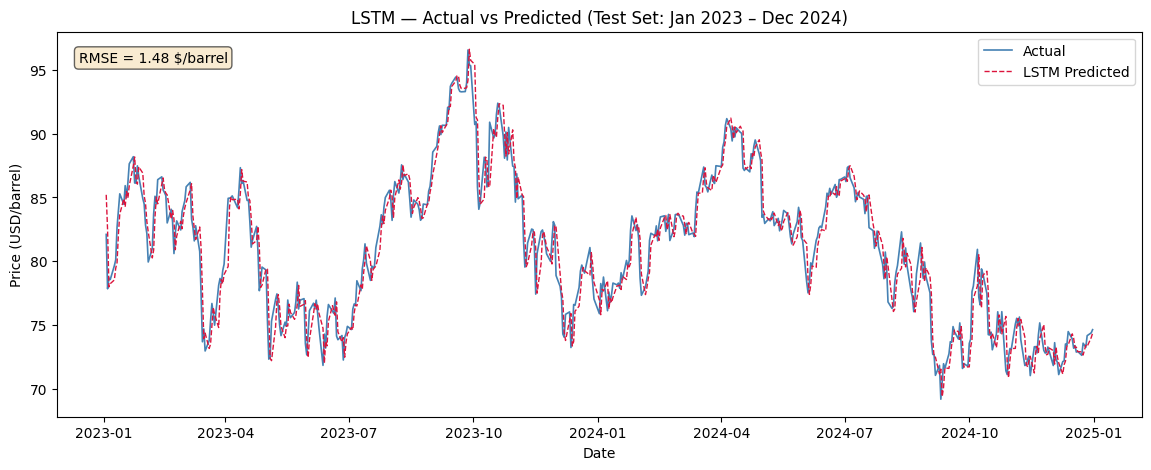

Plot saved.


In [9]:
# LSTM Actual vs Predicted plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_dates, y_test_lstm, label="Actual",
        color="steelblue", lw=1.2)
ax.plot(test_dates, y_pred_lstm, label="LSTM Predicted",
        color="crimson", lw=1.0, linestyle="--")
ax.text(0.02, 0.95,
        f"RMSE = {metrics_lstm['RMSE']:.2f} $/barrel",
        transform=ax.transAxes, fontsize=10,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.6))
ax.set_title("LSTM — Actual vs Predicted "
             "(Test Set: Jan 2023 – Dec 2024)")
ax.set_ylabel("Price (USD/barrel)")
ax.set_xlabel("Date")
ax.legend()
plt.savefig("artifacts/plots/lstm_actual_vs_predicted.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

In [10]:
# Save LSTM results
save_predictions(test_dates, y_test_lstm, y_pred_lstm,
                 "results/lstm/lstm_test_predictions.csv")
save_metrics(metrics_lstm,
             "results/lstm/lstm_metrics.json")

Predictions saved to results/lstm/lstm_test_predictions.csv
Metrics saved to results/lstm/lstm_metrics.json


In [11]:
# Build GRU model
tf.random.set_seed(42)
np.random.seed(42)

def build_gru(cfg):
    gc = cfg["models"]["gru"]
    model = Sequential([
        Input(shape=(gc["sequence_length"], 1)),
        GRU(gc["units"][0], return_sequences=True),
        GRU(gc["units"][1], return_sequences=False),
        Dense(25, activation="relu"),
        Dense(1)
    ], name="GRU_model")
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mean_squared_error"
    )
    return model

gru_model = build_gru(cfg)
gru_model.summary()

Model: "GRU_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │           825 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,123 (90.32 KB)

 Trainable params: 23,123 (90.32 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Train GRU model
gc = cfg["models"]["gru"]
os.makedirs("results/gru", exist_ok=True)

gru_callbacks = [
    EarlyStopping(monitor="val_loss",
                  patience=20,
                  restore_best_weights=True,
                  verbose=1),
    ModelCheckpoint("results/gru/best_gru_model.keras",
                    monitor="val_loss",
                    save_best_only=True,
                    verbose=0),
    ReduceLROnPlateau(monitor="val_loss",
                      factor=0.5,
                      patience=8,
                      min_lr=0.00001,
                      verbose=1)
]

print("Training GRU model...")
gru_history = gru_model.fit(
    X_train_s, y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=150,
    batch_size=32,
    callbacks=gru_callbacks,
    verbose=1
)
print("GRU training complete.")

Training GRU model...
Epoch 1/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.0123 - val_loss: 6.4156e-04 - learning_rate: 0.0010
Epoch 2/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 2.1228e-04 - val_loss: 6.4132e-04 - learning_rate: 0.0010
Epoch 3/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 2.1234e-04 - val_loss: 5.6647e-04 - learning_rate: 0.0010
Epoch 4/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 1.9913e-04 - val_loss: 5.2719e-04 - learning_rate: 0.0010
Epoch 5/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 1.8900e-04 - val_loss: 4.9729e-04 - learning_rate: 0.0010
Epoch 6/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 1.8115e-04 - val_loss: 4.7688e-04 - learning_rate: 0.0010
Epoch 7/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - loss: 1.7490e-04 - val_loss: 4.5722e-04 - learning_rate: 0.0010
Epoch 8/150
167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 1.7005e-04 - val_loss: 4.4662e-04 - learning_rate: 0.0010
Epoch 9/150
167/167 ━━

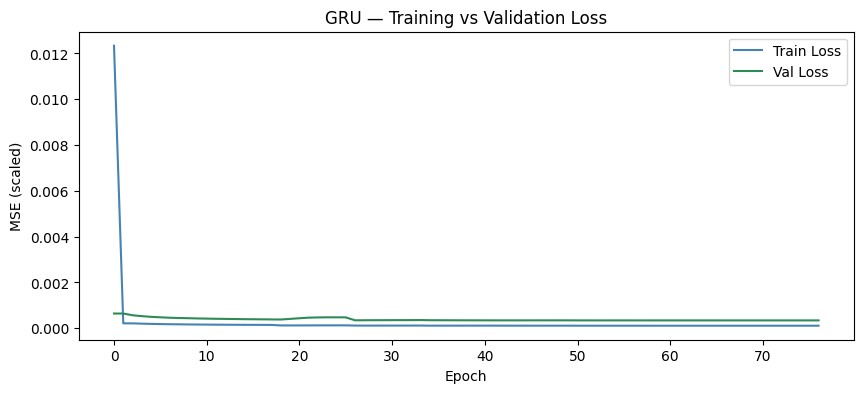

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
─── Metrics ──────────────────────
  RMSE : 1.4730 $/barrel
  MAE  : 1.1287 $/barrel
  MAPE : 1.4073 %

─── GRU Test Set Metrics ─────────────────────────────
  RMSE : 1.4730 $/barrel
  MAE  : 1.1287 $/barrel
  MAPE : 1.4073 %

Current standings:
  Random Forest : 1.3744 $/barrel
  XGBoost       : 1.4477 $/barrel
  ARIMA         : 1.4584 $/barrel
  LSTM          : 1.4838 $/barrel
  GRU           : 1.4730 $/barrel


In [13]:
# Plot GRU training loss
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(gru_history.history["loss"],
        label="Train Loss", color="steelblue")
ax.plot(gru_history.history["val_loss"],
        label="Val Loss", color="seagreen")
ax.set_title("GRU — Training vs Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (scaled)")
ax.legend()
plt.savefig("artifacts/plots/gru_training_loss.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Predict and inverse transform
y_pred_gru_sc = gru_model.predict(X_test).flatten()
y_pred_gru    = scaler.inverse_transform(
                    y_pred_gru_sc.reshape(-1, 1)).flatten()
y_test_gru    = scaler.inverse_transform(
                    y_test_sc.reshape(-1, 1)).flatten()

metrics_gru = calculate_metrics(y_test_gru, y_pred_gru)

print("\n─── GRU Test Set Metrics ─────────────────────────────")
print(f"  RMSE : {metrics_gru['RMSE']:.4f} $/barrel")
print(f"  MAE  : {metrics_gru['MAE']:.4f} $/barrel")
print(f"  MAPE : {metrics_gru['MAPE']:.4f} %")
print(f"\nCurrent standings:")
print(f"  Random Forest : 1.3744 $/barrel")
print(f"  XGBoost       : 1.4477 $/barrel")
print(f"  ARIMA         : 1.4584 $/barrel")
print(f"  LSTM          : 1.4838 $/barrel")
print(f"  GRU           : {metrics_gru['RMSE']:.4f} $/barrel")

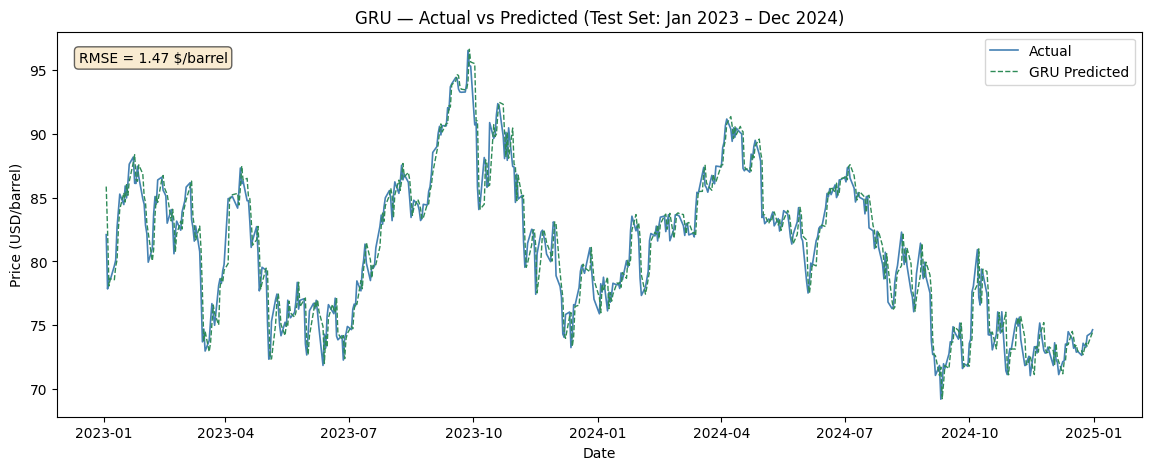

Plot saved.


In [14]:
# GRU Actual vs Predicted plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_dates, y_test_gru, label="Actual",
        color="steelblue", lw=1.2)
ax.plot(test_dates, y_pred_gru, label="GRU Predicted",
        color="seagreen", lw=1.0, linestyle="--")
ax.text(0.02, 0.95,
        f"RMSE = {metrics_gru['RMSE']:.2f} $/barrel",
        transform=ax.transAxes, fontsize=10,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.6))
ax.set_title("GRU — Actual vs Predicted "
             "(Test Set: Jan 2023 – Dec 2024)")
ax.set_ylabel("Price (USD/barrel)")
ax.set_xlabel("Date")
ax.legend()
plt.savefig("artifacts/plots/gru_actual_vs_predicted.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

In [15]:
# Save GRU results
save_predictions(test_dates, y_test_gru, y_pred_gru,
                 "results/gru/gru_test_predictions.csv")
save_metrics(metrics_gru,
             "results/gru/gru_metrics.json")

Predictions saved to results/gru/gru_test_predictions.csv
Metrics saved to results/gru/gru_metrics.json


### Deep Learning Results

### Performance summary
| Model | RMSE ($/barrel) | MAE ($/barrel) | MAPE (%) |
|-------|----------------|----------------|----------|
| LSTM | 1.4838 | 1.1431 | 1.42% |
| GRU | 1.4730 | 1.1287 | 1.41% |

### Key findings
- GRU outperforms LSTM on all three metrics — consistent with 
  Zhang and Lahmiri (2025) who found GRU the best standalone 
  deep learning model on Brent data
- GRU trains faster than LSTM (77 epochs vs 150) with fewer 
  parameters (23,123 vs 30,163)
- Both deep learning models underperform Random Forest (RMSE=1.37) 
  on this stable 2023-2024 test period
- The smooth GRU loss curve shows healthy convergence with no 
  overfitting
- LSTM required retraining after initial dropout caused poor 
  convergence — final architecture removed dropout layers

### Benchmark context
- Daneshvar et al. (2022) achieved LSTM RMSE=1.53 on Brent data 
  (2015-2021) — this project LSTM RMSE=1.48 represents improvement
- Both models beat the Mohammad and Panigrahi (2023) RMSE=21 
  baseline by over 93%